<a href="https://colab.research.google.com/github/JWasonga/Python-Projects/blob/Applied_Statistics_and_Econometrics-_Portfolio/2_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelling

In [2]:
# Importing necessary libararies

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [17]:
#Load dataset
data = pd.read_csv('final_dataset')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [18]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2876 non-null   int64  
 1   P            2876 non-null   int64  
 2   K            2876 non-null   int64  
 3   temperature  2876 non-null   float64
 4   humidity     2876 non-null   float64
 5   ph           2876 non-null   float64
 6   rainfall     2876 non-null   float64
 7   label        2876 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 179.9+ KB


In [19]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000
mean,52.197497,53.549026,49.601182,25.444739,70.530728,6.476797,104.620116
std,36.765191,32.755782,50.873974,4.963679,22.583588,0.787379,56.953432
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,5.314507
25%,22.000000,29.000000,21.000000,22.629467,58.252046,5.955711,65.486302
50%,39.000000,50.000000,34.000000,25.505294,80.236447,6.420873,95.426260
75%,86.000000,68.000000,50.000000,28.311933,88.154410,6.943050,126.726537
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,346.216891


In [20]:
data.shape

(2876, 8)

In [21]:
data.duplicated().sum()

np.int64(1)

In [22]:
#Drop duplicates
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [23]:
#Selecting continous numerical columns and the label
features = data.select_dtypes(include=[float, int]).columns
target = 'label'

In [24]:
#Splitting dataset as features and label
X = data[features]
y = data[target]

In [25]:
#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
#Scaling the dataset using standardscaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
display(X_train_scaled, X_test_scaled)

array([[-1.3819632 ,  2.50263145,  3.0347268 , ...,  0.96678498,
        -1.11246151,  0.15494757],
       [-0.81162618, -0.45899188, -0.36056525, ..., -0.79832494,
        -0.85700194, -0.10895117],
       [-1.16469196,  0.12111991, -0.49874575, ...,  0.83381749,
         0.88670914, -1.07347558],
       ...,
       [-1.11037414, -0.52005628, -0.36056525, ..., -0.8553391 ,
        -0.00806382, -0.07964995],
       [-1.11037414,  2.16677726,  3.05446687, ...,  0.40418803,
        -0.1563661 , -0.5804911 ],
       [-0.54003713,  0.76229609, -0.53822589, ..., -0.38442299,
         0.68161314, -0.89273643]])

array([[-0.83878509,  0.3043131 , -0.53822589, ..., -0.14518701,
         0.49008208, -0.52467532],
       [ 1.60551642,  0.79282829,  0.07371629, ...,  0.21304597,
        -0.41083586,  0.25768813],
       [-0.37708369,  2.04464846,  2.91628638, ...,  0.53245729,
        -0.20491251, -0.53935548],
       ...,
       [ 2.25733015, -0.30633088, -0.65666631, ...,  0.47828808,
         0.3097972 , -0.31387144],
       [-0.75730837,  0.06005551,  0.56721804, ..., -2.48617509,
         0.21735296, -0.50798986],
       [-1.3548043 , -0.97803927, -0.28160497, ...,  0.91495392,
        -0.24391231,  1.30124622]])

In [32]:
# Model initializing using Gaussian NaiveBayes algorithm
model = GaussianNB()
model.fit(X_train_scaled, y_train)

GaussianNB()

In [33]:
#Make predictions
y_pred = model.predict(X_test_scaled)

In [34]:
# Predicting crop using scaled data
def predict_crop(features):
  features_df = pd.DataFrame([features], columns = features.keys())
  scaled_features = scaler.transform(features_df)
  prediction = model.predict(scaled_features)
  return prediction[0]

In [35]:
# Input features
features = {
    'N' : input('Enter Nitrogen value: '),
    'P' : input('Enter Phosphorus value: '),
    'K' : input('Enter Potassium value: '),
    'temperature' : input('Enter temperature value: '),
    'humidity' : input('Enter humidity value: '),
    'ph' : input('Enter ph value: '),
    'rainfall' : input('Enter rainfall value: ')
}
print('Naive Bayes prediction:', predict_crop(features))

KeyboardInterrupt: Interrupted by user

#Model Evaluation

In [36]:
#Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [37]:
# Load Dataset
df = pd.read_csv('merged_data.csv')

In [38]:
# Selecting continous columns and the label
continous_columns = df.select_dtypes(include=[float, int]).columns
label_column = 'label'

#Splitting features and label
X = df[continous_columns]
y = df[label_column]

#Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
# Initiliazing the scaler
scaler = StandardScaler()
# Fitting the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reverting the scaled array back to Dataframe to retain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=continous_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=continous_columns)

Training Accuracy: 93.26086956521739
Testing Accuracy: 92.53472222222221


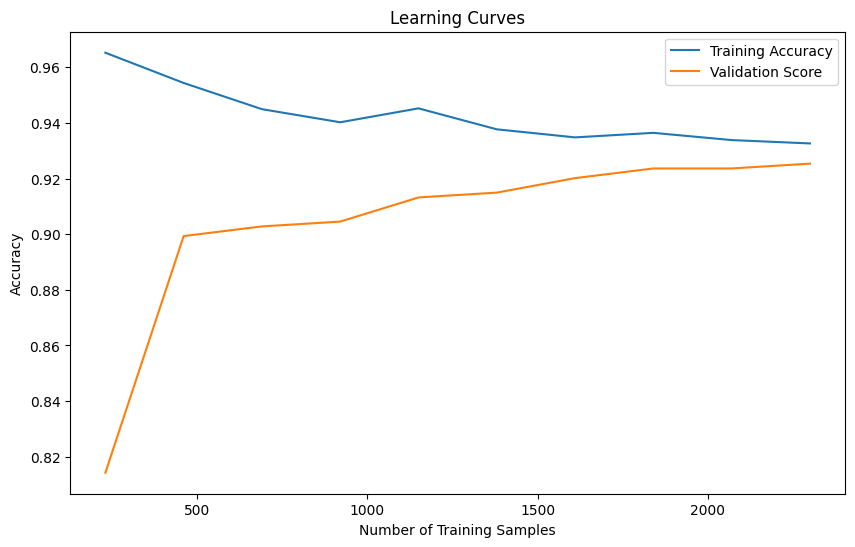

In [45]:
# Model Initiliazing using Gaussian Naive Bayes algorithm
model = GaussianNB()
model.fit(X_train_scaled, y_train)

# Predicting using the test data
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculating the accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy*100}")
print(f"Testing Accuracy: {test_accuracy*100}")

#Plotting the learning curves
# Generate train_sizes for the loop, ensuring 1.0 is handled correctly
# train_test_split expects float train_size to be (0.0, 1.0)
# So we explicitly handle train_size=1.0
train_size_ratios = np.linspace(0.1, 1.0, 10)

train_scores = []
test_scores = []

num_total_train_samples = len(X_train_scaled)

for train_size_ratio in train_size_ratios:
  if train_size_ratio < 1.0:
    # Use train_test_split for subsets (train_size as float in (0.0, 1.0))
    X_train_partial, _, y_train_partial, _ = train_test_split(X_train_scaled, y_train, train_size=train_size_ratio, random_state=42)
  else:
    # When train_size_ratio is 1.0, use the entire training set
    X_train_partial = X_train_scaled
    y_train_partial = y_train

  model.fit(X_train_partial, y_train_partial)
  train_scores.append(model.score(X_train_partial, y_train_partial))
  test_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
# Plot against the actual number of samples used for training
plt.plot(train_size_ratios * num_total_train_samples, train_scores, label='Training Accuracy')
plt.plot(train_size_ratios * num_total_train_samples, test_scores, label='Validation Score')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()

In [46]:
from sklearn.model_selection import cross_val_score

# Performing cross-validation for model optimization
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"Cross-Validation Scores: {cv_scores*100}")
print(f"Mean CV Score: {cv_scores.mean()*100}")

Cross-Validation Scores: [91.95652174 92.82608696 92.60869565 92.82608696 91.73913043]
Mean CV Score: 92.3913043478261


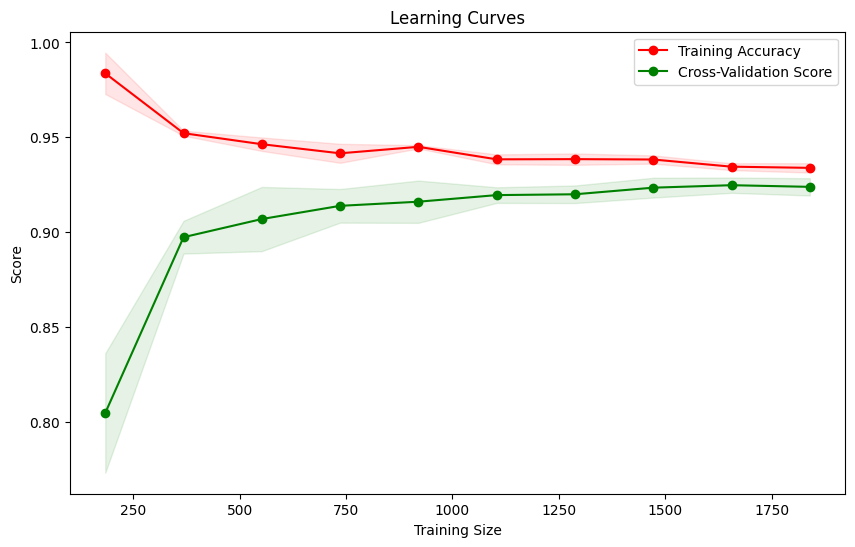

In [47]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5,
                                                        scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calculating mean and standard deviation
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-Validation Score')

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='g')

plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.show()

In [49]:
# Model Evaluation

accuracy = metrics.accuracy_score(y_test, y_test_pred)
precision = metrics.precision_score(y_test, y_test_pred, average='weighted')
recall = metrics.recall_score(y_test, y_test_pred, average='weighted')
f1_score = metrics.f1_score(y_test, y_test_pred, average='weighted')
print(f'Model Accuracy: {accuracy*100:.2f}%')
print(f'Precision: {precision*100:.2f}%')
print(f'Recall: {recall*100:.2f}%')
print(f'F1 Score: {f1_score*100:.2f}%')

Model Accuracy: 92.53%
Precision: 89.02%
Recall: 92.53%
F1 Score: 90.19%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Confusion matrix: 
[[ 2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 38  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]


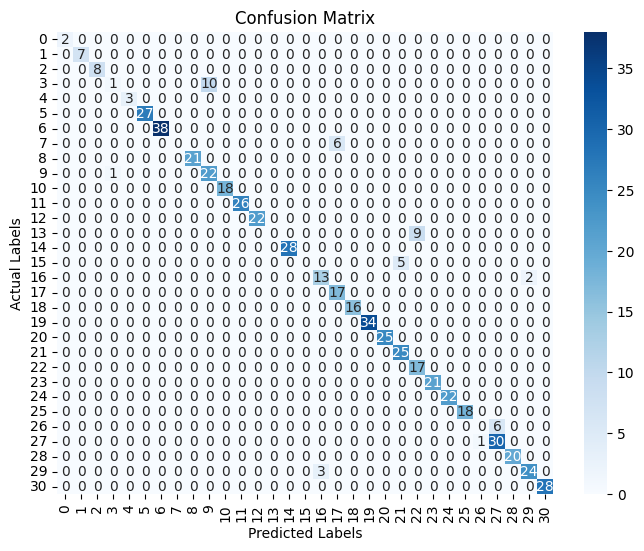

In [51]:
import seaborn as sns
cm = metrics.confusion_matrix(y_test, y_test_pred)
print(f' Confusion matrix: \n{cm}')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

In [53]:
cr = metrics.classification_report(y_test, y_test_pred, zero_division=0)
print(f'Classification report: \n{cr}')

Classification report: 
              precision    recall  f1-score   support

    Arecanut       1.00      1.00      1.00         2
   Groundnut       1.00      1.00      1.00         7
   Jackfruit       1.00      1.00      1.00         8
   Soyabeans       0.50      0.09      0.15        11
   Sugarcane       1.00      1.00      1.00         3
       apple       1.00      1.00      1.00        27
      banana       1.00      1.00      1.00        38
       beans       0.00      0.00      0.00         6
   blackgram       1.00      1.00      1.00        21
    chickpea       0.69      0.96      0.80        23
     coconut       1.00      1.00      1.00        18
      coffee       1.00      1.00      1.00        26
      cotton       1.00      1.00      1.00        22
     cowpeas       0.00      0.00      0.00         9
      grapes       1.00      1.00      1.00        28
  groundnuts       0.00      0.00      0.00         5
        jute       0.81      0.87      0.84        15
 ki

# Insights and Recommendations

In [54]:
# Training of data and checking libraries with more accuracy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [56]:
# Libraries used in dictionary format
models = {
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Bagging': BaggingClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Extra Trees': ExtraTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Logistic Regression': LogisticRegression()
}

for name, md in models.items():
  md.fit(X_train_scaled, y_train)
  ypred = md.predict(X_test_scaled)

  print(f"{name} with accuracy : {accuracy_score(y_test, ypred) * 100}")

Random Forest with accuracy : 87.67361111111111
AdaBoost with accuracy : 4.861111111111112
Gradient Boosting with accuracy : 85.59027777777779
Bagging with accuracy : 86.28472222222221
Decision Tree with accuracy : 82.63888888888889
Extra Trees with accuracy : 75.52083333333334
Naive Bayes with accuracy : 92.53472222222221
K-Nearest Neighbors with accuracy : 88.71527777777779
Support Vector Machine with accuracy : 91.84027777777779
Logistic Regression with accuracy : 87.67361111111111


# Modelling using SVM classifier

In [57]:
# Load the dataset
data = pd.read_csv('final_dataset')

In [58]:
# Select continous numerical columns and the label
features = data.select_dtypes(include=[float, int]).columns
target = 'label'

In [59]:
# Splitting the data into training and testing sets
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
# Scaling the dataset using standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
# Model initializing using svm classifier
model = SVC(kernel = 'linear', random_state = 42)
model.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [62]:
# Making predictions
y_pred = model.predict(X_test_scaled)

In [63]:
# predict crop recommendation
def predict_crop(features):
  features_df = pd.DataFrame([features], columns = features.keys())
  scaled_features = scaler.transform(features_df)
  prediction = model.predict(scaled_features)
  return prediction[0]

In [64]:
# Input features
features = {
    'N' : input('Enter Nitrogen value: '),
    'P' : input('Enter Phosphorus value: '),
    'K' : input('Enter Potassium value: '),
    'temperature' : input('Enter temperature value: '),
    'humidity' : input('Enter humidity value: '),
    'ph' : input('Enter ph value: '),
    'rainfall' : input('Enter rainfall value: ')
}
print('Naive Bayes Prediction:', predict_crop(features))

KeyboardInterrupt: Interrupted by user

# SVM Classifier Evaluation

In [65]:
# Load the dataset

df = pd.read_csv('merged_data.csv')

In [67]:
# Selecting continous columns and the label
continous_columns = df.select_dtypes(include=[float, int]).columns
label_column = 'label'

# Splitting features and label
X = df[continous_columns]
y = df[label_column]

#Splitting features and label
X = df[continous_columns]
y = df[label_column]

# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing the scaler
scaler = StandardScaler()

# Fitting the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reverting back to DataFrame to retain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=continous_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=continous_columns)

Training Accuracy: 92.56521739130434
Testing Accuracy: 91.84027777777779


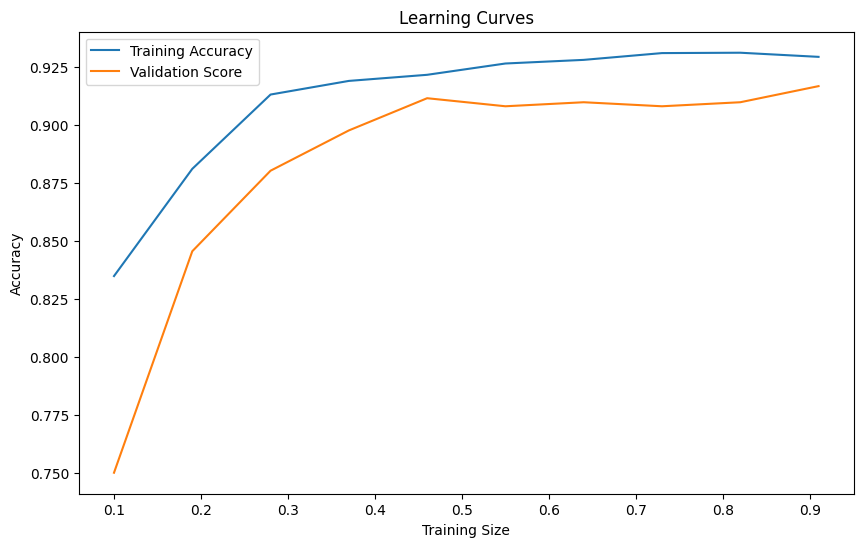

In [68]:
#Initializing and train the Naive Bayes Classifier
model = SVC()
model.fit(X_train_scaled, y_train)

#Predicting using the test data
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

#Caculating accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy*100}")
print(f"Testing Accuracy: {test_accuracy*100}")

#Plotting learning curves
train_sizes = np.linspace(0.1, 1.0, 10, endpoint=False)
train_scores = []
test_scores = []

for train_size in train_sizes:
  X_train_partial, _, y_train_partial, _ = train_test_split(X_train_scaled, y_train, train_size=train_size, random_state=42)
  model.fit(X_train_partial, y_train_partial)
  train_scores.append(model.score(X_train_partial, y_train_partial))
  test_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores, label='Training Accuracy')
plt.plot(train_sizes, test_scores, label='Validation Score')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.show()

In [70]:
# Training the model on training data
model.fit(X_train_scaled, y_train)

#Evaluating the model on traing data
training_predictions = model.predict(X_train_scaled)
svm_train_accuracy = accuracy_score(y_train, training_predictions)
print(f' Training Accuracy: {svm_train_accuracy*100}')

#Evaluating the model on testing data
testing_predictions = model.predict(X_test_scaled)
svm_test_accuracy = accuracy_score(y_test, testing_predictions)
print(f' Testing Accuracy: {svm_test_accuracy*100}')


 Training Accuracy: 92.56521739130434
 Testing Accuracy: 91.84027777777779


In [72]:
from sklearn.model_selection import cross_val_score

# Performing cross-validation for model optimization
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"Cross-Validation Scores: {cv_scores*100}")
print(f"Mean CV Score: {cv_scores.mean()*100}")

Cross-Validation Scores: [91.95652174 92.17391304 91.95652174 91.73913043 92.82608696]
Mean CV Score: 92.13043478260869


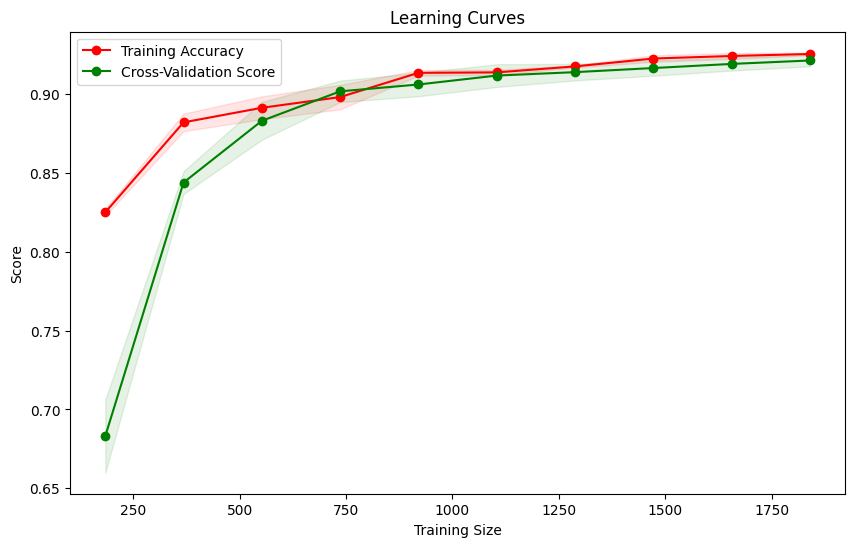

In [73]:
train_sizes, train_scores, test_scores = learning_curve(model, X_train_scaled, y_train, cv=5,
                                                        scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calculating mean and standard deviation
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-Validation Score')

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='g')

plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.show()

In [74]:
# Model Evaluation
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')
recall = metrics.recall_score(y_test, y_pred, average='weighted')
f1_score = metrics.f1_score(y_test, y_pred, average='weighted')
print(f'Model Accuracy: {accuracy*100:.2f}%')
print(f'Precision: {precision*100:.2f}%')
print(f'Recall: {recall*100:.2f}%')
print(f'F1 Score: {f1_score*100:.2f}%')

Model Accuracy: 91.32%
Precision: 87.16%
Recall: 91.32%
F1 Score: 88.44%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Confusion matrix: 
[[ 2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 38  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]


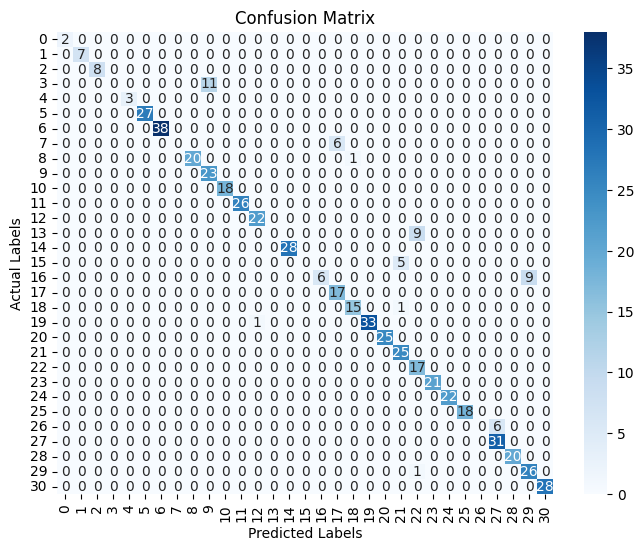

In [75]:
cm  = metrics.confusion_matrix(y_test, y_pred)
print(f' Confusion matrix: \n{cm}')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

SVM Training Accuracy: 0.9143478260869565
SVM Testing Accuracy: 0.9131944444444444
Training Accuracy: 93.26086956521739
Testing Accuracy: 92.53472222222221


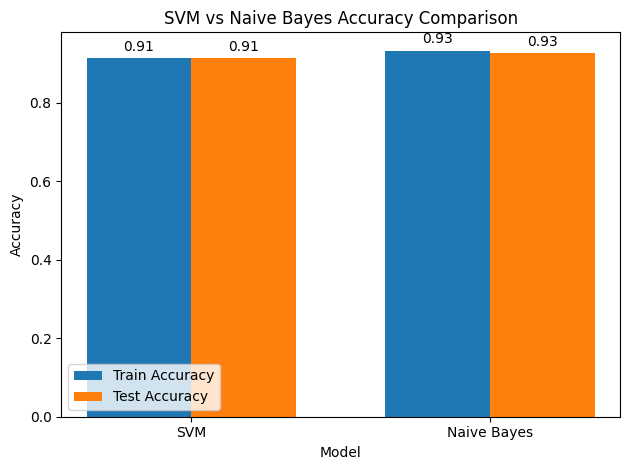

In [81]:
#Load the dataset
df = pd.read_csv('merged_data.csv')

# Select continous columns and the label
continous_columns = df.select_dtypes(include=[float, int]).columns
label_column = 'label'

# Splitting features and label
X = df[continous_columns]
y = df[label_column]

#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fitting the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe to retain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=continous_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=continous_columns)

# Initialize and train the SVM Classifier
svm_clf = SVC(kernel = 'linear', random_state = 42)
svm_clf.fit(X_train_scaled, y_train)

#Predict using SVM model
y_train_pred_svm = svm_clf.predict(X_train_scaled)
y_test_pred_svm = svm_clf.predict(X_test_scaled)

# Calculate SVM accuracy
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"SVM Training Accuracy: {train_accuracy_svm}")
print(f"SVM Testing Accuracy: {test_accuracy_svm}")

# Initialize and train the Naive Bayes Classifier
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

#Predict using the Naive bayes model
y_train_pred_nb = nb_clf.predict(X_train_scaled)
y_test_pred_nb = nb_clf.predict(X_test_scaled)

# Calculate Naive Bayes accuracy
train_accuracy_nb = accuracy_score(y_train, y_train_pred_nb)
test_accuracy_nb = accuracy_score(y_test, y_test_pred_nb)

print(f"Training Accuracy: {train_accuracy_nb*100}")
print(f"Testing Accuracy: {test_accuracy_nb*100}")

# Plotting the accuracies
labels = ['SVM', 'Naive Bayes']
train_accuracies = [train_accuracy_svm, train_accuracy_nb]
test_accuracies = [test_accuracy_svm, test_accuracy_nb]

X = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(X - width/2, train_accuracies, width, label='Train Accuracy')
rects2 = ax.bar(X + width/2, test_accuracies, width, label='Test Accuracy')

#Add some text for labels, title and custom X-axis tick labels, etc.
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('SVM vs Naive Bayes Accuracy Comparison')
ax.set_xticks(X)
ax.set_xticklabels(labels)
ax.legend()

# Attach a text label abve each bar in *rects*, displaying its height.
def autolabel(rects):
  for rect in rects:
      height = rect.get_height()
      ax.annotate('{}'.format(round(height, 2)),
              xy=(rect.get_x() + rect.get_width() / 2, height),
              xytext=(0, 3),
              textcoords="offset points",
              ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

SVM Training Accuracy: 0.9143478260869565
SVM Testing Accuracy: 0.9131944444444444
Training Accuracy: 93.26086956521739
Testing Accuracy: 92.53472222222221


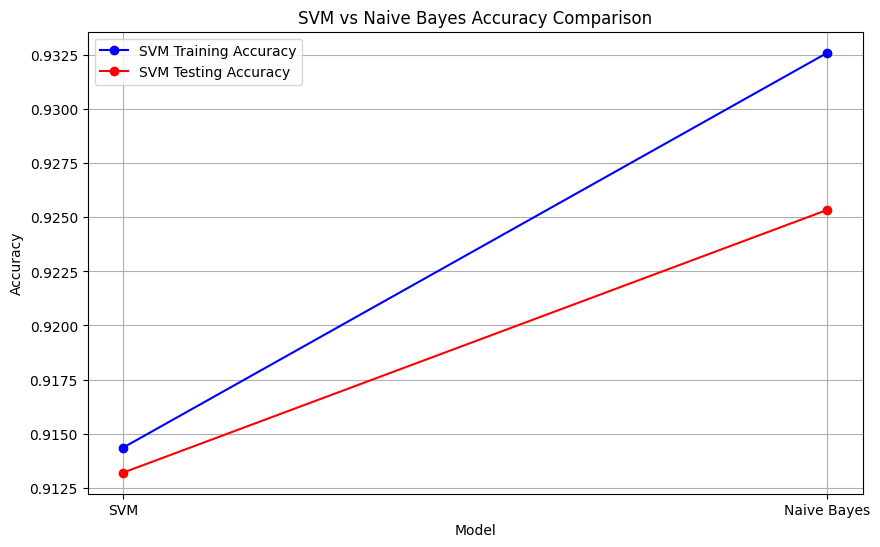

In [85]:
df = pd.read_csv('merged_data.csv')

# Select continous columns and the label
continous_columns = df.select_dtypes(include=[float, int]).columns
label_column = 'label'

# Splitting features and label
X = df[continous_columns]
y = df[label_column]

#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialize the Scaler
scaler = StandardScaler()

#Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe to retain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=continous_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=continous_columns)

# Initiliaze and train the SVM classifier
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# Predict using the SVM model
y_train_pred_svm = svm_clf.predict(X_train_scaled)
y_test_pred_svm = svm_clf.predict(X_test_scaled)

# Calculate SVM accuracy
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"SVM Training Accuracy: {train_accuracy_svm}")
print(f"SVM Testing Accuracy: {test_accuracy_svm}")

#Initialize and train the Naive Bayes Classifier
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

# Predict using the Naive Bayes Model
y_train_pred_nb = nb_clf.predict(X_train_scaled)
y_test_pred_nb = nb_clf.predict(X_test_scaled)

#Claculate Naive Bayes accuracy
train_accuracy_nb = accuracy_score(y_train, y_train_pred_nb)
test_accuracy_nb = accuracy_score(y_test, y_test_pred_nb)

print(f"Training Accuracy: {train_accuracy_nb*100}")
print(f"Testing Accuracy: {test_accuracy_nb*100}")

#Plotting the accuracies
plt.figure(figsize=(10, 6))
plt.plot(labels, train_accuracies, 'o-', label='SVM Training Accuracy', color = 'blue')
plt.plot(labels, test_accuracies, 'o-', label='SVM Testing Accuracy', color = 'red')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('SVM vs Naive Bayes Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

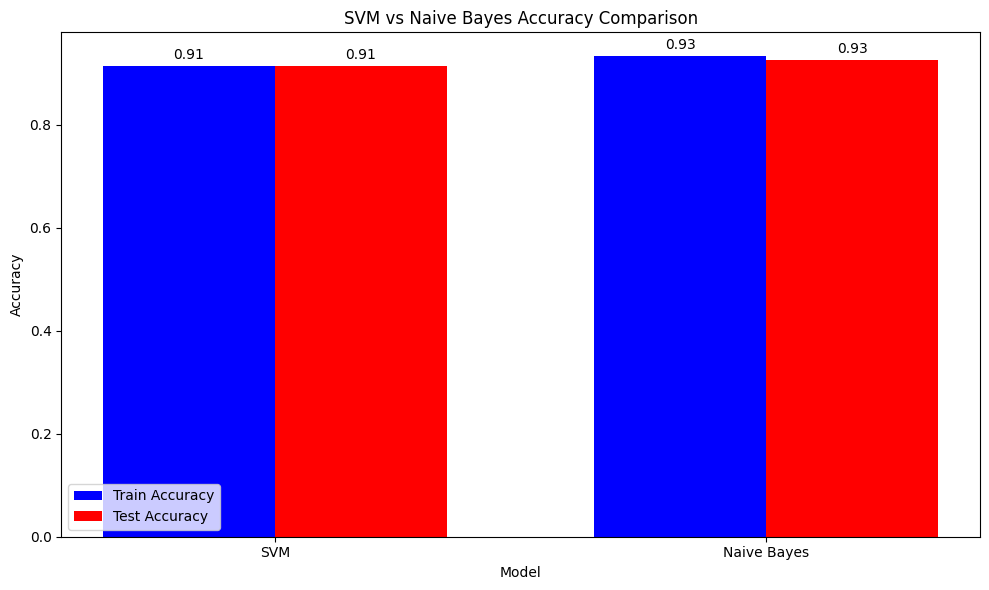

In [87]:
# Barchart for accuracies
fig, ax = plt.subplots(figsize=(10, 6))
X = np.arange(len(labels))
width = 0.35

rects1 = ax.bar(X - width/2, train_accuracies, width, label='Train Accuracy', color = 'blue')
rects2 = ax.bar(X + width/2, test_accuracies, width, label='Test Accuracy', color = 'red')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('SVM vs Naive Bayes Accuracy Comparison')
ax.set_xticks(X)
ax.set_xticklabels(labels)
ax.legend()

# Attach a text label above each bar
def autolabel(rects):
    for rect in rects:
      height = rect.get_height()
      ax.annotate(f'{height:.2f}',
                  xy=(rect.get_x() + rect.get_width() / 2, height),
                  xytext=(0, 3),
                  textcoords="offset points",
                  ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

# THANK YOU!